## 1. Setup and configuration

In [20]:
## Cell 1
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import warnings

# Deprecation warnings suppression
warnings.filterwarnings('ignore', category=FutureWarning)

PROCESSED_DIR = Path("../data/processed")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Rolling window
TRAIN_DAYS = 750
TRADE_DAYS = 250
VALIDATION_FRACTION = 0.20          

# Logistic regression hyperparameter search 
N_CS = 100                        
CV_FOLDS = 5                       
MAX_ITER = 100                      

# Trading strategy 
K_LONG_SHORT = 10              

# Cumulative-return feature horizons 31 features
CUMULATIVE_RETURN_HORIZONS = list(range(1, 21)) + list(range(40, 241, 20))
assert len(CUMULATIVE_RETURN_HORIZONS) == 31

print(f"K_LONG_SHORT = {K_LONG_SHORT}, N_CS = {N_CS}, CV_FOLDS = {CV_FOLDS}")

K_LONG_SHORT = 10, N_CS = 100, CV_FOLDS = 5


## 2. Load the full price panel and precompute returns, target, and features once

In [21]:
## Cell 2
price_panel = pd.read_csv(PROCESSED_DIR / "price_panel.csv", index_col="date")
price_panel.index = pd.to_datetime(price_panel.index, format="mixed", dayfirst=True)

print(f"Price panel: {price_panel.shape[0]} dates x {price_panel.shape[1]} tickers "
      f"({price_panel.index.min().date()} to {price_panel.index.max().date()})")

daily_returns = price_panel.pct_change()
forward_returns = daily_returns.shift(-1)  

next_day_returns = daily_returns.shift(-1)
daily_median = next_day_returns.median(axis=1)
targets = next_day_returns.ge(daily_median, axis=0).astype(float)
targets[next_day_returns.isna()] = np.nan

print(f"Targets: {targets.shape}, overall class balance: "
      f"{targets.stack().value_counts(normalize=True).round(3).to_dict()}")


Price panel: 6511 dates x 609 tickers (1990-01-02 to 2015-10-30)
Targets: (6511, 609), overall class balance: {1.0: 0.509, 0.0: 0.491}


In [22]:
## Cell 3
cum_return_panels = {}
for m in CUMULATIVE_RETURN_HORIZONS:
    cum_return_panels[m] = price_panel / price_panel.shift(m) - 1

print(f"Precomputed {len(cum_return_panels)} cumulative-return feature panels.")

Precomputed 31 cumulative-return feature panels.


## 3. Rolling study-period generator 

In [23]:
## Cell 4
def generate_study_periods(dates: pd.DatetimeIndex, train_days: int = TRAIN_DAYS,
                            trade_days: int = TRADE_DAYS) -> list[dict]:
    study_length = train_days + trade_days
    periods = []
    start_idx = 0
    period_num = 1
    while start_idx + study_length <= len(dates):
        train_start_idx = start_idx
        train_end_idx = start_idx + train_days - 1
        trade_start_idx = train_end_idx + 1
        trade_end_idx = start_idx + study_length - 1
        periods.append({
            "study_period": period_num,
            "train_start_date": dates[train_start_idx], "train_end_date": dates[train_end_idx],
            "trade_start_date": dates[trade_start_idx], "trade_end_date": dates[trade_end_idx],
        })
        start_idx += trade_days
        period_num += 1
    return periods


study_periods = generate_study_periods(price_panel.index)
print(f"Generated {len(study_periods)} study periods "
      f"(paper: 23; expected combined test coverage: up to {len(study_periods) * TRADE_DAYS} trading days)")


Generated 23 study periods (paper: 23; expected combined test coverage: up to 5750 trading days)


## 4. Per-period feature building, fitting, and prediction

In [24]:
## Cell 5
def build_period_features(period: dict) -> pd.DataFrame:
    all_dates = price_panel.loc[period["train_start_date"]: period["trade_end_date"]].index
    feature_frames = []
    for m in CUMULATIVE_RETURN_HORIZONS:
        panel_slice = cum_return_panels[m].loc[all_dates]
        feature_frames.append(panel_slice.stack().rename(f"ret_{m}d"))
    features = pd.concat(feature_frames, axis=1)
    features.index.names = ["date", "ticker"]

    tgt_slice = targets.loc[all_dates].stack()
    tgt_slice.index.names = ["date", "ticker"]

    data = features.join(tgt_slice.rename("target"), how="inner").dropna()
    return data


def split_period(data: pd.DataFrame, period: dict):
    train_dates = price_panel.loc[period["train_start_date"]: period["train_end_date"]].index
    trade_dates = price_panel.loc[period["trade_start_date"]: period["trade_end_date"]].index

    n_val_days = int(len(train_dates) * VALIDATION_FRACTION)
    chrono_train_dates = train_dates[:-n_val_days]
    chrono_val_dates = train_dates[-n_val_days:]

    idx_dates = data.index.get_level_values("date")
    train_df = data[idx_dates.isin(chrono_train_dates)]
    val_df = data[idx_dates.isin(chrono_val_dates)]
    test_df = data[idx_dates.isin(trade_dates)]
    return train_df, val_df, test_df


def fit_and_predict_one_period(period: dict, n_cs: int = N_CS):
    data = build_period_features(period)
    train_df, val_df, test_df = split_period(data, period)

    if len(train_df) == 0 or len(test_df) == 0:
        return None  

    feature_cols = [c for c in data.columns if c != "target"]
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[feature_cols].values)
    X_val = scaler.transform(val_df[feature_cols].values) if len(val_df) else np.empty((0, len(feature_cols)))
    X_test = scaler.transform(test_df[feature_cols].values)

    y_train = train_df["target"].values
    y_val = val_df["target"].values if len(val_df) else np.array([])
    y_test = test_df["target"].values

    tscv = TimeSeriesSplit(n_splits=CV_FOLDS)
    
    # LogisticRegressionCV without deprecated arguments
    model = LogisticRegressionCV(
        Cs=n_cs, 
        cv=tscv, 
        solver="lbfgs",
        max_iter=MAX_ITER, 
        scoring="accuracy", 
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    test_probs = model.predict_proba(X_test)[:, 1]

    period_predictions = test_df.reset_index()[["date", "ticker", "target", "ret_5d"]].copy()
    period_predictions["pred_prob"] = test_probs
    period_predictions["study_period"] = period["study_period"]

    return {
        "predictions": period_predictions,
        "selected_C": model.C_[0],
        "n_train": len(y_train), "n_val": len(y_val), "n_test": len(y_test),
        "train_correct": int((model.predict(X_train) == y_train).sum()),
        "val_correct": int((model.predict(X_val) == y_val).sum()) if len(y_val) else 0,
        "test_correct": int((model.predict(X_test) == y_test).sum()),
        "y_train": y_train, "y_val": y_val,
        "feature_cols": feature_cols, "coef": model.coef_[0],
    }

print("Per-period functions defined.")

Per-period functions defined.


## 5. Run the rolling loop across all study periods

In [25]:
## Cell 6
all_predictions = []
period_summaries = []
all_y_train, all_y_val = [], []
all_coefs = []
feature_cols = None  
running = {"train_correct": 0, "train_n": 0, "val_correct": 0, "val_n": 0,
           "test_correct": 0, "test_n": 0}

t0 = time.time()
for period in study_periods:
    t_period_start = time.time()
    result = fit_and_predict_one_period(period)
    elapsed = time.time() - t_period_start

    if result is None:
        print(f"Period {period['study_period']:2d}: SKIPPED (insufficient data)")
        continue

    all_predictions.append(result["predictions"])
    all_y_train.append(result["y_train"])
    all_y_val.append(result["y_val"])
    all_coefs.append(result["coef"])
    if feature_cols is None:
        feature_cols = result["feature_cols"]

    running["train_correct"] += result["train_correct"]; running["train_n"] += result["n_train"]
    running["val_correct"] += result["val_correct"]; running["val_n"] += result["n_val"]
    running["test_correct"] += result["test_correct"]; running["test_n"] += result["n_test"]

    period_summaries.append({
        "study_period": period["study_period"],
        "train_start": period["train_start_date"].date(), "trade_start": period["trade_start_date"].date(),
        "n_train": result["n_train"], "n_val": result["n_val"], "n_test": result["n_test"],
        "selected_C": result["selected_C"],
        "train_acc": result["train_correct"] / result["n_train"] if result["n_train"] else np.nan,
        "test_acc": result["test_correct"] / result["n_test"] if result["n_test"] else np.nan,
        "seconds": round(elapsed, 1),
    })

    print(f"Period {period['study_period']:2d}: "
          f"n_train={result['n_train']:>7,} | C={result['selected_C']:.5f} | "
          f"test_acc={period_summaries[-1]['test_acc']:.4f} | {elapsed:.1f}s")

    if period["study_period"] == 1:
        est_total = elapsed * len(study_periods) / 60
        print(f"  --> Estimated total runtime for all {len(study_periods)} periods: "
              f"~{est_total:.1f} minutes (based on period 1's time)")

total_elapsed = time.time() - t0
print(f"\nRolling loop complete: {len(all_predictions)}/{len(study_periods)} periods used, "
      f"{total_elapsed/60:.1f} minutes total.")


Period  1: n_train=106,268 | C=0.00015 | test_acc=0.5402 | 15.9s
  --> Estimated total runtime for all 23 periods: ~6.1 minutes (based on period 1's time)
Period  2: n_train=180,319 | C=0.00077 | test_acc=0.5344 | 15.1s
Period  3: n_train=187,660 | C=0.00196 | test_acc=0.5380 | 15.1s
Period  4: n_train=198,250 | C=0.01048 | test_acc=0.5283 | 13.4s
Period  5: n_train=208,053 | C=0.00021 | test_acc=0.5179 | 12.6s
Period  6: n_train=218,078 | C=0.00236 | test_acc=0.5096 | 13.1s
Period  7: n_train=226,316 | C=0.00093 | test_acc=0.5090 | 13.8s
Period  8: n_train=235,572 | C=0.00413 | test_acc=0.5177 | 14.7s
Period  9: n_train=244,370 | C=0.05591 | test_acc=0.5098 | 14.2s
Period 10: n_train=253,100 | C=0.00025 | test_acc=0.5089 | 15.8s
Period 11: n_train=260,650 | C=0.00010 | test_acc=0.5103 | 15.7s
Period 12: n_train=269,397 | C=0.00010 | test_acc=0.5066 | 15.3s
Period 13: n_train=276,552 | C=0.00017 | test_acc=0.5060 | 15.4s
Period 14: n_train=281,103 | C=0.00010 | test_acc=0.5079 | 13.7s


## 6. Combine all periods into one series and build the variables the evaluation add-on expects


In [26]:
## Cell 7
test_predictions = pd.concat(all_predictions, ignore_index=True)
y_train = np.concatenate(all_y_train)
y_val = np.concatenate(all_y_val)
y_test = test_predictions["target"].values

avg_coefs = pd.Series(np.mean(all_coefs, axis=0), index=feature_cols)
coef_std = pd.Series(np.std(all_coefs, axis=0), index=feature_cols)

train_acc = running["train_correct"] / running["train_n"] if running["train_n"] else np.nan
val_acc = running["val_correct"] / running["val_n"] if running["val_n"] else np.nan
test_acc = running["test_correct"] / running["test_n"] if running["test_n"] else np.nan

n_combined_days = test_predictions["date"].nunique()
print(f"Combined test predictions: {len(test_predictions):,} (date, ticker) rows "
      f"across {n_combined_days:,} trading days")
print(f"(Paper: 5750 trading days. This run covers {n_combined_days:,} -- "
      f"{'matches' if n_combined_days == 5750 else 'differs from'} the paper's total.)")
print(f"\nPooled accuracy -- train: {train_acc:.4f} | val: {val_acc:.4f} | test: {test_acc:.4f}")

print(f"\nAverage coefficient across {len(all_coefs)} periods, largest |coef| first:")
print(avg_coefs.reindex(avg_coefs.abs().sort_values(ascending=False).index).head(10).round(4))
print("(coef_std above/below this shows how stable each feature's sign/magnitude is across periods)")

period_summary_df = pd.DataFrame(period_summaries)
period_summary_df.to_csv(RESULTS_DIR / "rolling_all_periods_summary.csv", index=False)
test_predictions.to_csv(RESULTS_DIR / "rolling_all_periods_test_predictions.csv", index=False)

print(f"\nSaved: results/rolling_all_periods_summary.csv, "
      f"results/rolling_all_periods_test_predictions.csv")
period_summary_df


Combined test predictions: 2,683,205 (date, ticker) rows across 5,750 trading days
(Paper: 5750 trading days. This run covers 5,750 -- matches the paper's total.)

Pooled accuracy -- train: 0.5155 | val: 0.5124 | test: 0.5106

Average coefficient across 23 periods, largest |coef| first:
ret_1d    -0.0236
ret_2d    -0.0228
ret_6d    -0.0198
ret_3d    -0.0102
ret_19d   -0.0099
ret_12d   -0.0087
ret_5d     0.0082
ret_20d    0.0068
ret_13d    0.0067
ret_60d   -0.0058
dtype: float64
(coef_std above/below this shows how stable each feature's sign/magnitude is across periods)

Saved: results/rolling_all_periods_summary.csv, results/rolling_all_periods_test_predictions.csv


,study_period,train_start,trade_start,n_train,n_val,n_test,selected_C,train_acc,test_acc,seconds
0,1,1990-01-02,1992-12-17,106268,45542,79753,0.000145,0.536747,0.540180,15.9
1,2,1990-12-27,1993-12-14,180319,48334,83490,0.000774,0.538412,0.534435,15.1
2,3,1991-12-23,1994-12-09,187660,50815,88384,0.001963,0.538239,0.538016,15.1
3,4,1992-12-17,1995-12-06,198250,53377,91625,0.010476,0.539294,0.528349,13.4
4,5,1993-12-14,1996-12-02,208053,55446,95741,0.000210,0.536234,0.517897,12.6
5,6,1994-12-09,1997-11-26,218078,57672,98745,0.002364,0.533217,0.509616,13.1
6,7,1995-12-06,1998-11-24,226316,59795,103626,0.000933,0.523887,0.509004,13.8
7,8,1996-12-02,1999-11-22,235572,62540,105969,0.004132,0.514921,0.517736,14.7
8,9,1997-11-26,2000-11-16,244370,63970,109854,0.055908,0.512293,0.509786,14.2
9,10,1998-11-24,2001-11-20,253100,66349,113162,0.000254,0.515014,0.508881,15.8


## 7. Sanity checks before handing off to the evaluation add-on


In [27]:
## Cell 8
print("=== Combined predictions sanity checks ===")
print(f"Any NaN in pred_prob? {test_predictions['pred_prob'].isna().any()}")
print(f"Any NaN in target?    {test_predictions['target'].isna().any()}")
print(f"Overall test class balance: {test_predictions['target'].mean():.4f}")
print(f"Tickers represented: {test_predictions['ticker'].nunique()}")
print(f"Date range: {test_predictions['date'].min().date()} to {test_predictions['date'].max().date()}")

dupes = test_predictions.groupby("date")["study_period"].nunique()
print(f"\nDates claimed by more than one study period: {(dupes > 1).sum()} (should be 0)")

avg_eligible_per_day = test_predictions.groupby("date").size()
print(f"\nEligible stocks per test day -- min: {avg_eligible_per_day.min()}, "
      f"median: {avg_eligible_per_day.median():.0f}, max: {avg_eligible_per_day.max()}")
print(f"(K_LONG_SHORT={K_LONG_SHORT} needs at least {2*K_LONG_SHORT} eligible stocks per day "
      f"for both legs to be filled; days below this are skipped by the backtest.)")


=== Combined predictions sanity checks ===
Any NaN in pred_prob? False
Any NaN in target?    False
Overall test class balance: 0.5059
Tickers represented: 599
Date range: 1992-12-17 to 2015-10-15

Dates claimed by more than one study period: 0 (should be 0)

Eligible stocks per test day -- min: 310, median: 470, max: 599
(K_LONG_SHORT=10 needs at least 20 eligible stocks per day for both legs to be filled; days below this are skipped by the backtest.)


## Prerequisites and configuration

In [28]:
## Cell 9
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

_required = ["test_predictions", "forward_returns", "price_panel", "K_LONG_SHORT",
             "RESULTS_DIR", "PROCESSED_DIR", "y_train", "y_val", "y_test",
             "train_acc", "val_acc", "test_acc"]

_missing = [v for v in _required if v not in globals()]

if _missing:
    # standalone mode: rebuild everything from files saved by Notebooks 2 and 3 
    import joblib
    from sklearn.metrics import accuracy_score

    def _find_project_root():
        here = Path.cwd().resolve()
        for p in [here, *here.parents][:6]:
            if (p / "data" / "processed" / "price_panel.csv").exists():
                return p
        return None

    ROOT = _find_project_root()
    if ROOT is None:
        raise RuntimeError("Could not find the project folder (looked for data/processed/price_panel.csv "
                           f"starting from {Path.cwd()}). Put this notebook in the project's notebooks/ folder, "
                           "or paste its cells at the end of Notebook 3.")

    PROCESSED_DIR = ROOT / "data" / "processed"
    STUDY_DIR = PROCESSED_DIR / "study_period_0"
    RESULTS_DIR = ROOT / "results"
    model_path = RESULTS_DIR / "baseline_logreg_model.joblib"
    if not model_path.exists():
        raise RuntimeError(f"{model_path} not found. Run Notebook 3 top to bottom once (its last code cell saves the model).")

    def _load_split(name):
        df = pd.read_csv(STUDY_DIR / f"benchmark_{name}.csv")
        df["date"] = pd.to_datetime(df["date"], format="mixed", dayfirst=True)
        return df.set_index(["date", "ticker"])

    bundle = joblib.load(model_path)
    logreg_cv, scaler, feature_cols = bundle["model"], bundle["scaler"], bundle["feature_cols"]
    K_LONG_SHORT = bundle.get("k_long_short", 3)

    train_df, val_df, test_df = (_load_split(n) for n in ("train", "val", "test"))
    y_train, y_val, y_test = (d["target"].values for d in (train_df, val_df, test_df))
    X_train, X_val, X_test = (scaler.transform(d[feature_cols].values) for d in (train_df, val_df, test_df))
    train_acc = accuracy_score(y_train, logreg_cv.predict(X_train))
    val_acc = accuracy_score(y_val, logreg_cv.predict(X_val))
    test_acc = accuracy_score(y_test, logreg_cv.predict(X_test))

    test_predictions = test_df.copy()
    test_predictions["pred_prob"] = logreg_cv.predict_proba(X_test)[:, 1]
    test_predictions = test_predictions.reset_index()

    price_panel = pd.read_csv(PROCESSED_DIR / "price_panel.csv", index_col="date")
    price_panel.index = pd.to_datetime(price_panel.index, format="mixed", dayfirst=True)
    forward_returns = price_panel.pct_change().shift(-1)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Standalone mode: variables rebuilt from saved files under {ROOT}")
else:
    print("Notebook 3 variables found in memory.")

TRADING_DAYS = 252
COST_PER_HALF_TURN = 0.0005                  # [PAPER] 5 bps per half-turn
PAPER_COST_PER_DAY = 4 * COST_PER_HALF_TURN  # [INFERRED] 20 bps/day = 2 legs x 2 half-turns, full daily turnover
RF_DAILY = 0.0                               # no risk-free series yet (Kenneth French RF is a later, external download)
N_MONKEYS = 10_000                           # paper uses 100,000; reduced for runtime, raise if you like
K_SWEEP = [1, 2, 3, 4, 5]                    # paper: 10, 50, 100, 150, 200 (needs ~500 stocks
RNG_SEED = 42

print(f"Test rows: {len(test_predictions)} | K_LONG_SHORT = {K_LONG_SHORT}")
print(f"Paper-style cost per daily rebalance: {PAPER_COST_PER_DAY:.4f} ({PAPER_COST_PER_DAY*1e4:.0f} bps)")


Notebook 3 variables found in memory.
Test rows: 2683205 | K_LONG_SHORT = 10
Paper-style cost per daily rebalance: 0.0020 (20 bps)


##  Detailed backtest 

In [29]:
## Cell 10
def run_long_short_detailed(predictions, fwd_returns, k, verbose=True):
    """Rank by pred_prob each day; long top-k, short bottom-k (unit weight per leg).
    Returns (daily_df, picks_df). Days with < 2k eligible stocks are skipped."""
    daily_rows, pick_rows = [], []
    prev_long, prev_short = set(), set()
    skipped = 0

    for date, g in predictions.groupby("date"):
        if len(g) < 2 * k or date not in fwd_returns.index:
            skipped += 1
            continue
        ranked = g.sort_values("pred_prob", ascending=False)
        top, flop = ranked.iloc[:k], ranked.iloc[-k:]
        long_r = fwd_returns.loc[date, top["ticker"].values].to_numpy(dtype=float)
        short_r = fwd_returns.loc[date, flop["ticker"].values].to_numpy(dtype=float)
        if np.isnan(long_r).all() or np.isnan(short_r).all():
            skipped += 1
            continue

        long_mean, short_mean = np.nanmean(long_r), np.nanmean(short_r)
        cur_long, cur_short = set(top["ticker"]), set(flop["ticker"])
        turn_long = 1 - len(cur_long & prev_long) / k     
        turn_short = 1 - len(cur_short & prev_short) / k
        prev_long, prev_short = cur_long, cur_short

        daily_rows.append({
            "date": date,
            "long_ret": long_mean, "short_ret": short_mean,
            "long_contrib": long_mean,            
            "short_contrib": -short_mean,         
            "ls_return": long_mean - short_mean,  
            "turn_long": turn_long, "turn_short": turn_short,
            "n_eligible": len(g),
        })
        for side, part, rets in ((1, top, long_r), (-1, flop, short_r)):
            for (_, row), fr in zip(part.iterrows(), rets):
                pick_rows.append({"date": date, "ticker": row["ticker"], "side": side,
                                  "pred_prob": row["pred_prob"], "target": row["target"],
                                  "fwd_return": fr})

    daily = pd.DataFrame(daily_rows)
    picks = pd.DataFrame(pick_rows)
    if len(daily) == 0:
        raise RuntimeError(
            f"No usable trading days for k={k}: every day had fewer than 2*k={2*k} "
            f"eligible stocks (or forward returns were all missing). "
            f"{skipped} day(s) skipped out of {predictions['date'].nunique()}. "
            f"Reduce k, or check that `forward_returns` covers the same date range as `predictions`."
        )
    daily = daily.set_index("date")
    picks["correct"] = (((picks["side"] == 1) & (picks["target"] == 1)) |
                        ((picks["side"] == -1) & (picks["target"] == 0)))
    if verbose:
        print(f"k={k}: {len(daily)} days used, {skipped} skipped.")
    return daily, picks


def apply_costs(daily):
    out = daily.copy()
    out["net_paper"] = out["ls_return"] - PAPER_COST_PER_DAY
    out["cost_turnover"] = 2 * COST_PER_HALF_TURN * (out["turn_long"] + out["turn_short"])
    out["net_turnover"] = out["ls_return"] - out["cost_turnover"]
    return out


daily, picks = run_long_short_detailed(test_predictions, forward_returns, K_LONG_SHORT)
daily = apply_costs(daily)
print(f"Average daily turnover -- long leg: {daily['turn_long'].mean():.2f}, short leg: {daily['turn_short'].mean():.2f} "
      f"(1.00 = whole leg replaced every day, the paper-style assumption)")
daily.head()


k=10: 5750 days used, 0 skipped.
Average daily turnover -- long leg: 0.59, short leg: 0.63 (1.00 = whole leg replaced every day, the paper-style assumption)


,long_ret,short_ret,long_contrib,short_contrib,ls_return,turn_long,turn_short,n_eligible,net_paper,cost_turnover,net_turnover
date,,,,,,,,,,,
1992-12-17,0.004583,0.008871,0.004583,-0.008871,-0.004288,1.0,1.0,310,-0.006288,0.0020,-0.006288
1992-12-18,0.026026,-0.006660,0.026026,0.006660,0.032687,0.3,0.5,310,0.030687,0.0008,0.031887
1992-12-21,0.030291,-0.003945,0.030291,0.003945,0.034236,0.4,0.3,310,0.032236,0.0007,0.033536
1992-12-22,0.058466,0.003356,0.058466,-0.003356,0.055110,0.4,0.3,310,0.053110,0.0007,0.054410
1992-12-23,0.013089,-0.006830,0.013089,0.006830,0.019919,0.4,0.5,310,0.017919,0.0009,0.019019


In [30]:
## Cell 11
def newey_west_se_of_mean(x, lags=1):
    x = np.asarray(x, dtype=float)
    T = len(x)
    xm = x - x.mean()
    S = np.dot(xm, xm) / T
    for l in range(1, lags + 1):
        w = 1 - l / (lags + 1)                 # Bartlett weight
        S += 2 * w * np.dot(xm[l:], xm[:-l]) / T
    return np.sqrt(S / T)


def table3_metrics(r, long_contrib=None, short_contrib=None, rf_daily=RF_DAILY):
    r = pd.Series(r, dtype=float).dropna()
    n = len(r)
    mu, sd = r.mean(), r.std(ddof=1)
    se = newey_west_se_of_mean(r.to_numpy(), lags=1)

    wealth = np.concatenate([[1.0], np.cumprod(1 + r.to_numpy())])
    max_dd = float(np.max(1 - wealth / np.maximum.accumulate(wealth)))

    var1, var5 = r.quantile(0.01), r.quantile(0.05)
    ret_pa = wealth[-1] ** (TRADING_DAYS / n) - 1 if wealth[-1] > 0 else np.nan
    rf_pa = (1 + rf_daily) ** TRADING_DAYS - 1
    std_pa = sd * np.sqrt(TRADING_DAYS)
    dd_pa = np.sqrt(np.mean(np.minimum(r.to_numpy(), 0.0) ** 2)) * np.sqrt(TRADING_DAYS)

    m = {}
    # ---- Panel A: daily return characteristics
    m["A | Mean return (long leg)"] = long_contrib.mean() if long_contrib is not None else np.nan
    m["A | Mean return (short leg)"] = short_contrib.mean() if short_contrib is not None else np.nan
    m["A | Mean return"] = mu
    m["A | Newey-West std. error"] = se
    m["A | Newey-West t-statistic"] = mu / se if se > 0 else np.nan
    m["A | Minimum"] = r.min()
    m["A | Quartile 1"] = r.quantile(0.25)
    m["A | Median"] = r.median()
    m["A | Quartile 3"] = r.quantile(0.75)
    m["A | Maximum"] = r.max()
    m["A | Share > 0"] = (r > 0).mean()
    m["A | Standard dev. (daily)"] = sd
    m["A | Skewness"] = r.skew()
    m["A | Excess kurtosis"] = r.kurt()
    # ---- Panel B: daily risk
    m["B | 1% VaR"] = var1
    m["B | 1% CVaR"] = r[r <= var1].mean()
    m["B | 5% VaR"] = var5
    m["B | 5% CVaR"] = r[r <= var5].mean()
    m["B | Max. drawdown"] = max_dd
    # ---- Panel C: annualized
    m["C | Return p.a. (geometric)"] = ret_pa
    m["C | Excess return p.a. (rf = 0)"] = ret_pa - rf_pa
    m["C | Standard dev. p.a."] = std_pa
    m["C | Downside dev. p.a."] = dd_pa
    m["C | Sharpe ratio p.a. (paper-style)"] = (ret_pa - rf_pa) / std_pa if std_pa > 0 else np.nan
    m["C | Sortino ratio p.a. (paper-style)"] = ret_pa / dd_pa if dd_pa > 0 else np.nan
    m["C | Sharpe p.a. (arithmetic: mean/std x sqrt(252))"] = (mu - rf_daily) / sd * np.sqrt(TRADING_DAYS) if sd > 0 else np.nan
    m["n | Trading days"] = n
    return m

print("Metric functions defined.")


Metric functions defined.


##  Table 3-style report, incl. market benchmark

The market column uses the **S&P 500 index** (`^GSPC`, downloaded in Notebook 1) as a proxy for Kenneth French's market return used in the paper. `^GSPC` is a price index without dividends, so it understates the total market return slightly. Market returns are aligned to the **same realized-return days** as the strategy.


In [31]:
## Cell 12
spx_path = PROCESSED_DIR.parent / "raw" / "_SPX_benchmark.csv"
spx_fwd = None
if spx_path.exists():
    spx = pd.read_csv(spx_path)
    spx["date"] = pd.to_datetime(spx["date"], format="mixed", dayfirst=True)
    spx = spx.set_index("date").sort_index()
    spx_fwd = spx["close"].pct_change().shift(-1).reindex(daily.index).dropna()
else:
    print("S&P 500 benchmark file not found -- market column will be skipped.")

columns = {
    "Gross": table3_metrics(daily["ls_return"], daily["long_contrib"], daily["short_contrib"]),
    "Net: flat 20 bps/day [paper-style]": table3_metrics(
        daily["net_paper"], daily["long_contrib"] - 0.0010, daily["short_contrib"] - 0.0010),
    "Net: turnover-based [extension]": table3_metrics(
        daily["net_turnover"],
        daily["long_contrib"] - 0.0010 * daily["turn_long"],
        daily["short_contrib"] - 0.0010 * daily["turn_short"]),
}
if spx_fwd is not None:
    columns["S&P 500 (market proxy)"] = table3_metrics(spx_fwd)

table3 = pd.DataFrame(columns)
table3.to_csv(RESULTS_DIR / "baseline_logreg_table3_style.csv")

with pd.option_context("display.float_format", "{:,.4f}".format, "display.width", 200):
    print(table3.to_string())


                                                        Gross  Net: flat 20 bps/day [paper-style]  Net: turnover-based [extension]  S&P 500 (market proxy)
A | Mean return (long leg)                             0.0076                              0.0066                           0.0070                     NaN
A | Mean return (short leg)                            0.0016                              0.0006                           0.0010                     NaN
A | Mean return                                        0.0092                              0.0072                           0.0080                  0.0003
A | Newey-West std. error                              0.0007                              0.0007                           0.0007                  0.0001
A | Newey-West t-statistic                            13.4156                             10.4942                          11.6334                  2.2552
A | Minimum                                           -0.3222         

## Predictive accuracy: majority baseline, top/flop-k accuracy, binomial and Pesaran-Timmermann tests

In [32]:
## Cell 13
def pesaran_timmermann(y_true, y_pred):
    y, x = np.asarray(y_true, float), np.asarray(y_pred, float)
    n = len(y)
    p_hat = np.mean(x == y)
    py, px = y.mean(), x.mean()
    p_star = py * px + (1 - py) * (1 - px)
    v_hat = p_star * (1 - p_star) / n
    v_star = (((2 * py - 1) ** 2) * px * (1 - px) / n
              + ((2 * px - 1) ** 2) * py * (1 - py) / n
              + 4 * py * px * (1 - py) * (1 - px) / n ** 2)
    denom = v_hat - v_star
    if denom <= 0:
        return np.nan, np.nan
    stat = (p_hat - p_star) / np.sqrt(denom)
    return stat, 1 - sp_stats.norm.cdf(stat)


def majority_rate(y):
    y = np.asarray(y, float)
    return max(y.mean(), 1 - y.mean())


rows = []
for name, y_split, acc in (("train", y_train, train_acc), ("val", y_val, val_acc), ("test", y_test, test_acc)):
    rows.append({"set": f"all rows: {name}", "n": len(y_split), "accuracy": acc,
                 "benchmark": majority_rate(y_split), "benchmark_type": "majority class"})

n_tf, k_ok = len(picks), int(picks["correct"].sum())
acc_tf = k_ok / n_tf
try:
    p_binom = sp_stats.binomtest(k_ok, n_tf, 0.5, alternative="greater").pvalue
except AttributeError:   # very old scipy
    p_binom = 1 - sp_stats.norm.cdf((k_ok - 0.5 * n_tf) / np.sqrt(0.25 * n_tf))

pt_stat, pt_p = pesaran_timmermann(picks["target"], (picks["side"] == 1).astype(float))

base_rate = test_predictions.loc[test_predictions["date"].isin(daily.index), "target"].mean()
rows.append({"set": f"top/flop-{K_LONG_SHORT} picks (combined)", "n": n_tf, "accuracy": acc_tf,
             "benchmark": 0.5, "benchmark_type": "no-skill expectation"})
rows.append({"set": "  long picks only", "n": int((picks.side == 1).sum()),
             "accuracy": picks.loc[picks.side == 1, "correct"].mean(),
             "benchmark": base_rate, "benchmark_type": "share of target=1 on used days"})
rows.append({"set": "  short picks only", "n": int((picks.side == -1).sum()),
             "accuracy": picks.loc[picks.side == -1, "correct"].mean(),
             "benchmark": 1 - base_rate, "benchmark_type": "share of target=0 on used days"})

accuracy_report = pd.DataFrame(rows)
accuracy_report.to_csv(RESULTS_DIR / "baseline_logreg_accuracy_extended.csv", index=False)
with pd.option_context("display.float_format", "{:,.4f}".format, "display.width", 200):
    print(accuracy_report.to_string(index=False))

print(f"\nBinomial test (top/flop accuracy > 50%): p = {p_binom:.4f}   [optimistic: cross-sectional dependence]")
print(f"Pesaran-Timmermann: stat = {pt_stat:.3f}, one-sided p = {pt_p:.4f}")


                         set       n  accuracy  benchmark                 benchmark_type
             all rows: train 5972338    0.5155     0.5083                 majority class
               all rows: val 1574442    0.5124     0.5071                 majority class
              all rows: test 2683205    0.5106     0.5059                 majority class
top/flop-10 picks (combined)  115000    0.5350     0.5000           no-skill expectation
             long picks only   57500    0.5346     0.5059 share of target=1 on used days
            short picks only   57500    0.5354     0.4941 share of target=0 on used days

Binomial test (top/flop accuracy > 50%): p = 0.0000   [optimistic: cross-sectional dependence]
Pesaran-Timmermann: stat = 23.715, one-sided p = 0.0000


   n_days  mean_daily_return  std_p.a.  sharpe_p.a. (paper-style)  \
k                                                                   
1    5750             0.0373    6.4030                        NaN   
2    5750             0.0266    3.4366                        NaN   
3    5750             0.0207    2.3679                        NaN   
4    5750             0.0175    1.8237                    17.8890   
5    5750             0.0148    1.4838                    14.2973   

   topflop_accuracy  
k                    
1            0.5503  
2            0.5491  
3            0.5473  
4            0.5448  
5            0.5430  


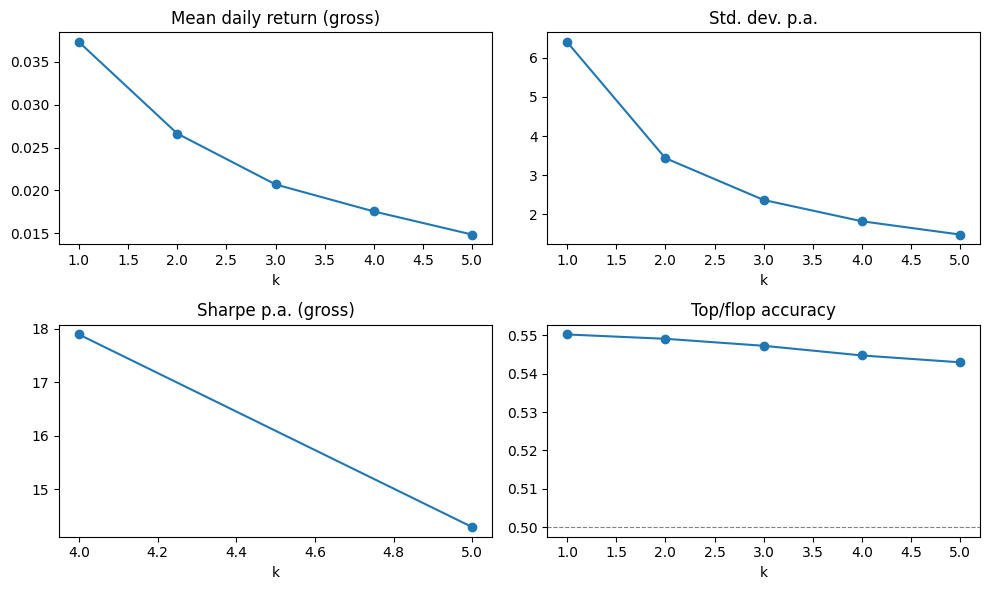

In [33]:
## Cell 14
sweep_rows = []
for k in K_SWEEP:
    d_k, p_k = run_long_short_detailed(test_predictions, forward_returns, k, verbose=False)
    if len(d_k) < 20:
        continue
    m_k = table3_metrics(d_k["ls_return"])
    sweep_rows.append({
        "k": k, "n_days": len(d_k),
        "mean_daily_return": m_k["A | Mean return"],
        "std_p.a.": m_k["C | Standard dev. p.a."],
        "sharpe_p.a. (paper-style)": m_k["C | Sharpe ratio p.a. (paper-style)"],
        "topflop_accuracy": p_k["correct"].mean(),
    })
sweep = pd.DataFrame(sweep_rows).set_index("k")
sweep.to_csv(RESULTS_DIR / "baseline_logreg_k_sweep.csv")
with pd.option_context("display.float_format", "{:,.4f}".format):
    print(sweep)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, col, title in zip(axes.ravel(),
                          ["mean_daily_return", "std_p.a.", "sharpe_p.a. (paper-style)", "topflop_accuracy"],
                          ["Mean daily return (gross)", "Std. dev. p.a.", "Sharpe p.a. (gross)", "Top/flop accuracy"]):
    ax.plot(sweep.index, sweep[col], marker="o")
    ax.set_title(title); ax.set_xlabel("k")
    if col == "topflop_accuracy":
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_logreg_k_sweep.png", dpi=150)
plt.show()


##  Random "monkey" portfolios 

**[PAPER]** draws 10 random longs and 10 random shorts each day (without replacement), over 100,000 replications ("monkeys"), and shows that even the best monkey (0.05%/day) is far below the models. Here each monkey uses the **same eligible stocks, same days, same k** as our strategy, gross of costs. The empirical one-sided p-value is the share of monkeys at least as good as the strategy: `(1 + #{monkey >= strategy}) / (N + 1)`.


10,000 monkeys over 5750 days | monkey mean = -0.00000 (should be ~0)
Best monkey: 0.00102 | strategy: 0.00918 | empirical one-sided p = 0.0001


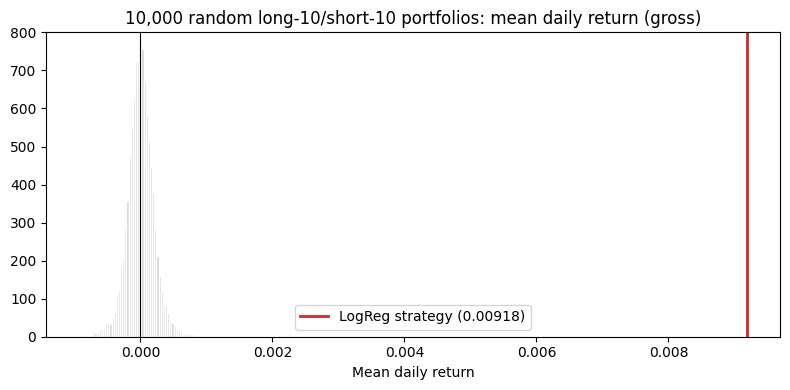

In [34]:
## CEll 15
def monkey_means(predictions, fwd_returns, k, n_monkeys=N_MONKEYS, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    day_arrays = []
    for date, g in predictions.groupby("date"):
        if len(g) < 2 * k or date not in fwd_returns.index:
            continue
        r = fwd_returns.loc[date, g["ticker"].values].to_numpy(dtype=float)
        r = r[~np.isnan(r)]
        if len(r) >= 2 * k:
            day_arrays.append(r)
    total = np.zeros(n_monkeys)
    for r in day_arrays:
        order = np.argsort(rng.random((n_monkeys, len(r))), axis=1)
        total += r[order[:, :k]].mean(axis=1) - r[order[:, k:2 * k]].mean(axis=1)
    return total / len(day_arrays), len(day_arrays)


monkeys, n_days_m = monkey_means(test_predictions, forward_returns, K_LONG_SHORT)
model_mean = daily["ls_return"].mean()
p_monkey = (1 + np.sum(monkeys >= model_mean)) / (len(monkeys) + 1)

print(f"{len(monkeys):,} monkeys over {n_days_m} days | monkey mean = {monkeys.mean():.5f} (should be ~0)")
print(f"Best monkey: {monkeys.max():.5f} | strategy: {model_mean:.5f} | empirical one-sided p = {p_monkey:.4f}")

plt.figure(figsize=(8, 4))
plt.hist(monkeys, bins=60, color="lightgray", edgecolor="white")
plt.axvline(model_mean, color="C3", linewidth=2, label=f"LogReg strategy ({model_mean:.5f})")
plt.axvline(0, color="black", linewidth=0.8)
plt.title(f"{len(monkeys):,} random long-{K_LONG_SHORT}/short-{K_LONG_SHORT} portfolios: mean daily return (gross)")
plt.xlabel("Mean daily return"); plt.legend(); plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_logreg_monkeys.png", dpi=150)
plt.show()


## Performance over time 
**[PAPER]** splits performance into 1993-2000, 2001-2009 and 2010-2015 and shows the edge fading.

In [35]:
## Cell 16
def performance_by_period(daily_df, picks_df, ret_col="ls_return", freq="M"):
    per = daily_df.index.to_period(freq)
    picks_per = pd.PeriodIndex(picks_df["date"], freq=freq)
    rows = []
    for p in per.unique():
        r = daily_df.loc[per == p, ret_col]
        acc = picks_df.loc[picks_per == p, "correct"].mean()
        sd = r.std(ddof=1)
        rows.append({"period": str(p), "n_days": len(r),
                     "mean_return_bp": r.mean() * 1e4,
                     "cumulative_return": (1 + r).prod() - 1,
                     "sharpe_arith": (r.mean() / sd * np.sqrt(TRADING_DAYS)) if sd > 0 else np.nan,
                     "topflop_accuracy": acc})
    return pd.DataFrame(rows).set_index("period")


by_period = performance_by_period(daily, picks, "ls_return", freq="Q")
by_period.to_csv(RESULTS_DIR / "baseline_logreg_by_period.csv")
with pd.option_context("display.float_format", "{:,.4f}".format):
    print(by_period)
print("\nNote: single-quarter Sharpe ratios rest on ~60 daily observations -- treat them as noise, not evidence.")


        n_days  mean_return_bp  cumulative_return  sharpe_arith  \
period                                                            
1992Q4      10        197.1938             0.2132       14.6169   
1993Q1      62         87.3092             0.6910        6.4929   
1993Q2      63         97.7532             0.8288        8.9318   
1993Q3      64        533.6374             6.8084        2.5790   
1993Q4      64         57.4893             0.4218        4.1652   
...        ...             ...                ...           ...   
2014Q4      64        136.2934             1.3109        7.0479   
2015Q1      61        155.3712             1.4591        6.4865   
2015Q2      63         81.1066             0.6315        5.0331   
2015Q3      64         40.3422             0.2653        2.3945   
2015Q4      11         32.1876             0.0288        1.3498   

        topflop_accuracy  
period                    
1992Q4            0.5600  
1993Q1            0.5444  
1993Q2            0.

##  Industry breakdown

Average over(+)/under(-) weight vs. eligible universe, percentage points:
group                   all 2k picks  flop-k (short)  top-k (long)
sector                                                            
Information Technology         14.93           15.03         13.76
Financials                     -7.60           -7.01         -8.40
Industrials                    -5.53           -5.77         -5.27
Utilities                      -5.47           -5.36         -5.60
Consumer Discretionary          4.58            4.85          4.78
Health Care                     4.66            4.47          4.51
Consumer Staples               -2.98           -2.89         -2.97
Real Estate                    -2.45           -2.83         -2.10
Communication Services          1.44            1.46          1.33
Energy                         -0.96           -1.13         -0.55
Materials                      -0.62           -0.90          0.29


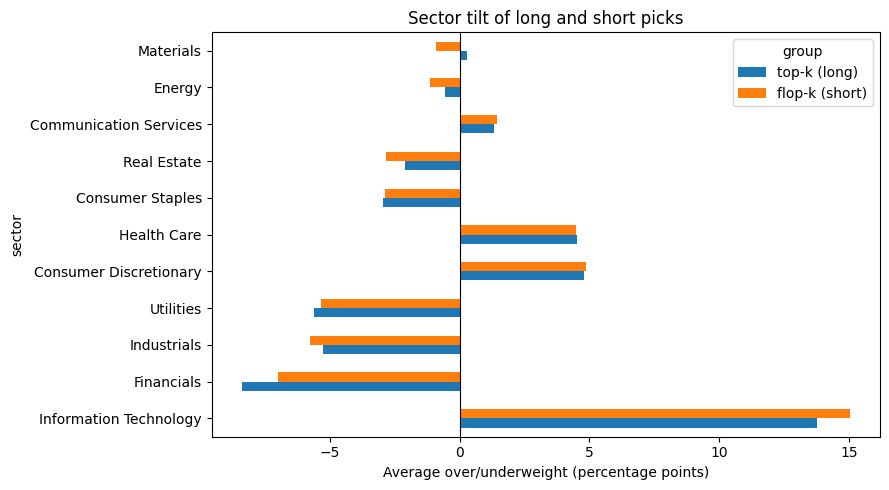

In [36]:
## Cell 17
company_info = pd.read_csv(PROCESSED_DIR / "company_info.csv")
sector_map = company_info.set_index("ticker")["gics_sector"].to_dict()
all_sectors = sorted({s for s in sector_map.values() if isinstance(s, str)})

def sector_share(tickers):
    s = pd.Series([sector_map.get(t, "Unknown") for t in tickers]).value_counts(normalize=True)
    return s.reindex(all_sectors, fill_value=0.0)

rows = []
for date, g in test_predictions.groupby("date"):
    if date not in daily.index:
        continue
    universe = sector_share(g["ticker"])
    p_day = picks[picks["date"] == date]
    for name, sub in (("top-k (long)", p_day[p_day.side == 1]),
                      ("flop-k (short)", p_day[p_day.side == -1]),
                      ("all 2k picks", p_day)):
        diff = sector_share(sub["ticker"]) - universe
        for sec, d in diff.items():
            rows.append({"group": name, "sector": sec, "diff_pp": d * 100})

industry = (pd.DataFrame(rows).groupby(["sector", "group"])["diff_pp"].mean().unstack("group"))
industry = industry.loc[industry.abs().sum(axis=1).sort_values(ascending=False).index]
industry.to_csv(RESULTS_DIR / "baseline_logreg_industry_tilt.csv")
with pd.option_context("display.float_format", "{:,.2f}".format):
    print("Average over(+)/under(-) weight vs. eligible universe, percentage points:")
    print(industry)

industry[["top-k (long)", "flop-k (short)"]].plot(kind="barh", figsize=(9, 5))
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Average over/underweight (percentage points)")
plt.title("Sector tilt of long and short picks")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_logreg_industry_tilt.png", dpi=150)
plt.show()


##  What do the picked stocks look like? 

Windows used: top=57500, flop=57500, all=2683205
                              Top-10 (long)  Flop-10 (short)  All eligible (mean)
Return_t_t-1                        -0.0422           0.0538               0.0008
Return_t_t-5                        -0.0829           0.1228               0.0039
Return_t_t-20                       -0.0767           0.1760               0.0148
Return_t-20_t-240 (momentum)         1.3453           0.2110               0.1923
Return_t_t-240                       1.2243           0.3912               0.2082
Rolling_std_5_days                   0.0484           0.0555               0.0200
Rolling_std_20_days                  0.0491           0.0536               0.0217
Rolling_std_t-20_t-240               0.0665           0.0575               0.0242
Rolling_std_240_days                 0.0665           0.0590               0.0242
Rolling_skew_240_days                0.5065           0.6421               0.1684
Rolling_kurt_240_days                9.8549      

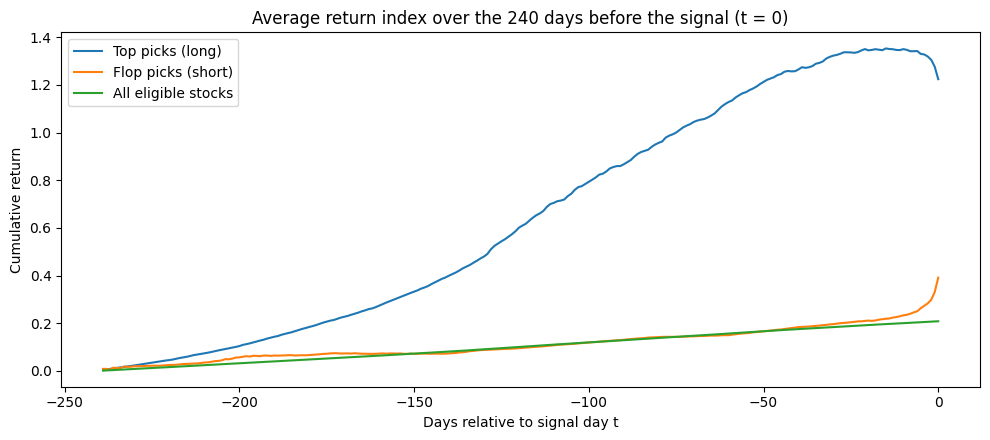

In [37]:
## CEll 18
W = 240
ret_mat = price_panel.pct_change()
ret_np = ret_mat.to_numpy()
date_pos = {d: i for i, d in enumerate(ret_mat.index)}
col_pos = {t: j for j, t in enumerate(ret_mat.columns)}

def get_window(date, ticker):
    i, j = date_pos.get(date), col_pos.get(ticker)
    if i is None or j is None or i < W:
        return None
    w = ret_np[i - W + 1: i + 1, j]
    return None if np.isnan(w).any() else w

def window_stats(w):
    s = pd.Series(w)
    return {
        "Return_t_t-1": w[-1],
        "Return_t_t-5": np.prod(1 + w[-5:]) - 1,
        "Return_t_t-20": np.prod(1 + w[-20:]) - 1,
        "Return_t-20_t-240 (momentum)": np.prod(1 + w[:-20]) - 1,
        "Return_t_t-240": np.prod(1 + w) - 1,
        "Rolling_std_5_days": w[-5:].std(ddof=1),
        "Rolling_std_20_days": w[-20:].std(ddof=1),
        "Rolling_std_t-20_t-240": w[:-20].std(ddof=1),
        "Rolling_std_240_days": w.std(ddof=1),
        "Rolling_skew_240_days": s.skew(),
        "Rolling_kurt_240_days": s.kurt(),
    }

top_keys = set(zip(picks.loc[picks.side == 1, "date"], picks.loc[picks.side == 1, "ticker"]))
flop_keys = set(zip(picks.loc[picks.side == -1, "date"], picks.loc[picks.side == -1, "ticker"]))

stat_rows, idx = [], {"top": [], "flop": [], "all": []}
for date, ticker in zip(test_predictions["date"], test_predictions["ticker"]):
    if date not in daily.index:
        continue
    w = get_window(date, ticker)
    if w is None:
        continue
    grp = "top" if (date, ticker) in top_keys else ("flop" if (date, ticker) in flop_keys else "other")
    st = window_stats(w); st["group"] = grp
    stat_rows.append(st)
    path = np.cumprod(1 + w) - 1
    idx["all"].append(path)
    if grp in ("top", "flop"):
        idx[grp].append(path)

char = pd.DataFrame(stat_rows)
feat = [c for c in char.columns if c != "group"]
char_table = pd.concat({
    f"Top-{K_LONG_SHORT} (long)": char[char.group == "top"][feat].mean(),
    f"Flop-{K_LONG_SHORT} (short)": char[char.group == "flop"][feat].mean(),
    "All eligible (mean)": char[feat].mean(),
}, axis=1)
char_table.to_csv(RESULTS_DIR / "baseline_logreg_pick_characteristics.csv")
with pd.option_context("display.float_format", "{:,.4f}".format, "display.width", 200):
    print(f"Windows used: top={len(idx['top'])}, flop={len(idx['flop'])}, all={len(idx['all'])}")
    print(char_table)

x = np.arange(-W + 1, 1)
plt.figure(figsize=(10, 4.5))
for key, label in (("top", "Top picks (long)"), ("flop", "Flop picks (short)"), ("all", "All eligible stocks")):
    if idx[key]:
        plt.plot(x, np.mean(idx[key], axis=0), label=label)
plt.title("Average return index over the 240 days before the signal (t = 0)")
plt.xlabel("Days relative to signal day t"); plt.ylabel("Cumulative return")
plt.legend(); plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_logreg_pick_return_index.png", dpi=150)
plt.show()


## Simplified short-term reversal strategy 

In [38]:
## Cell 19
rev_pred = test_predictions[["date", "ticker", "target", "ret_5d"]].copy()
rev_pred["pred_prob"] = -rev_pred["ret_5d"]      # most negative 5-day return ranks first (long)

rev_daily, rev_picks = run_long_short_detailed(rev_pred, forward_returns, K_LONG_SHORT)
rev_daily = apply_costs(rev_daily)

rev_cols = {
    "Reversal rule: gross": table3_metrics(rev_daily["ls_return"], rev_daily["long_contrib"], rev_daily["short_contrib"]),
    "Reversal rule: net (20 bps/day)": table3_metrics(rev_daily["net_paper"]),
}
rev_table = pd.DataFrame(rev_cols)
rev_table.to_csv(RESULTS_DIR / "short_term_reversal_rule_table3_style.csv")

corrs = []
for date, g in test_predictions.groupby("date"):
    if g["pred_prob"].nunique() > 1 and g["ret_5d"].nunique() > 1:
        corrs.append(g["pred_prob"].corr(-g["ret_5d"], method="spearman"))
mean_rank_corr = float(np.nanmean(corrs))

key_rows = ["A | Mean return", "A | Newey-West t-statistic", "B | Max. drawdown",
            "C | Sharpe ratio p.a. (paper-style)", "C | Sortino ratio p.a. (paper-style)"]
compare = pd.concat([table3[["Gross", "Net: flat 20 bps/day [paper-style]"]].loc[key_rows]
                     .rename(columns=lambda c: f"LogReg: {c}"),
                     rev_table.loc[key_rows]], axis=1)
with pd.option_context("display.float_format", "{:,.4f}".format, "display.width", 220):
    print(compare)
print(f"\nTop/flop accuracy of the reversal rule: {rev_picks['correct'].mean():.4f} "
      f"(LogReg: {acc_tf:.4f})")
print(f"Mean daily Spearman corr(LogReg score, -ret_5d): {mean_rank_corr:.3f}  "
      f"(+1 = identical ranking to the reversal rule, 0 = unrelated)")

if "avg_coefs" in globals():
    print("\nAverage LogReg coefficient across all study periods "
          "(largest |mean coef| first; std shows cross-period stability):")
    ranked = avg_coefs.reindex(avg_coefs.abs().sort_values(ascending=False).index).head(10)
    coef_report = pd.DataFrame({"mean_coef": ranked, "std_coef": coef_std.reindex(ranked.index)})
    print(coef_report.round(4))
elif "logreg_cv" in globals() and "feature_cols" in globals():
    # Notebook 3 case: a single fitted model for the one study period used.
    coefs = pd.Series(logreg_cv.coef_[0], index=feature_cols)
    print("\nLogReg coefficients on standardized features (largest |coef| first):")
    print(coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(10).round(4))
else:
    print("\n(No single model or per-period coefficients found in this kernel -- "
          "skipping the coefficient summary.)")


k=10: 5750 days used, 0 skipped.
                                      LogReg: Gross  LogReg: Net: flat 20 bps/day [paper-style]  Reversal rule: gross  Reversal rule: net (20 bps/day)
A | Mean return                              0.0092                                      0.0072                0.0083                           0.0063
A | Newey-West t-statistic                  13.4156                                     10.4942               12.2018                           9.2569
B | Max. drawdown                            0.5518                                      0.6369                0.5227                           0.6001
C | Sharpe ratio p.a. (paper-style)          8.4832                                      4.6606                6.6285                           3.5285
C | Sortino ratio p.a. (paper-style)        22.7464                                     11.9683               16.1484                           8.2804

Top/flop accuracy of the reversal rule: 0.5307 (LogReg: 0.53